In [4]:
import pandas as pd

dados = pd.read_csv('DENGBR25.csv', sep=',')

/tmp/ipython-input-31766338.py:3: DtypeWarning: Columns (44,45,46,54,74,101) have mixed types. Specify dtype option on import or set low_memory=False.
  dados = pd.read_csv('DENGBR25.csv', sep=',')


In [5]:
dados.shape

(1622438, 121)

### Quantidade de registros duplicados.

In [6]:
duplicados = dados[dados.duplicated()]

qtd_duplicados = dados.duplicated().sum()
print(f"Quantidade de registros duplicados: {qtd_duplicados}")

Quantidade de registros duplicados: 649




### Remoção de registros duplicados, que podem distorcer métricas, gerar vieses e prejudicar o modelo.

In [7]:
dados = dados.drop_duplicates()

In [8]:
dados.shape

(1621789, 121)

### Inferência sobre os dados - Avaliando as métricas

- Muitos campos com registros NaN, esses campos serão tratados um a um de acordo com sua particularidade no dicionário de dados. URL: https://s3.sa-east-1.amazonaws.com/ckan.saude.gov.br/SINAN/Dengue/dic_dados_dengue.pdf

- Colunas com 100% de nulos em seus registros serão excluídas.

- Visando obter para análise colunas com ≥ 70% de nulos em seus registros, na maioria dos casos essas colunas não agregam informação preditiva e aumentam o ruído, com exceções clínicas, por exemplo, variáveis de gravidade como: "hospitalizado" ou "obito", exames laboratoriais e sintomas como: "dores", "sangramentos" e "vomitos". Com base nesses critérios, serão feitos análises para remoção das colunas abaixo:


In [9]:
total_linhas = len(dados)

colunas_com_muitos_nulos = []

for coluna in dados.columns:
    porcentagem_nulos = dados[coluna].isna().mean() * 100

    if porcentagem_nulos >= 70:
        colunas_com_muitos_nulos.append(coluna)
        print(f"'{coluna}' - '{porcentagem_nulos:.2f}%'")


'ID_OCUPA_N' - '72.86%'
'DT_CHIK_S1' - '99.93%'
'DT_CHIK_S2' - '100.00%'
'DT_PRNT' - '99.98%'
'RES_CHIKS1' - '99.77%'
'RES_CHIKS2' - '99.79%'
'RESUL_PRNT' - '99.78%'
'DT_SORO' - '83.75%'
'DT_VIRAL' - '99.48%'
'DT_PCR' - '96.09%'
'SOROTIPO' - '97.09%'
'DT_INTERNA' - '95.99%'
'UF' - '95.95%'
'MUNICIPIO' - '96.01%'
'DOENCA_TRA' - '100.00%'
'CLINC_CHIK' - '99.65%'
'DT_OBITO' - '99.85%'
'ALRM_HIPOT' - '97.64%'
'ALRM_PLAQ' - '97.64%'
'ALRM_VOM' - '97.64%'
'ALRM_SANG' - '97.64%'
'ALRM_HEMAT' - '97.65%'
'ALRM_ABDOM' - '97.62%'
'ALRM_LETAR' - '97.64%'
'ALRM_HEPAT' - '97.65%'
'ALRM_LIQ' - '97.65%'
'DT_ALRM' - '97.69%'
'GRAV_PULSO' - '99.81%'
'GRAV_CONV' - '99.81%'
'GRAV_ENCH' - '99.81%'
'GRAV_INSUF' - '99.81%'
'GRAV_TAQUI' - '99.81%'
'GRAV_EXTRE' - '99.81%'
'GRAV_HIPOT' - '99.81%'
'GRAV_HEMAT' - '99.81%'
'GRAV_MELEN' - '99.81%'
'GRAV_METRO' - '99.81%'
'GRAV_SANG' - '99.81%'
'GRAV_AST' - '99.81%'
'GRAV_MIOC' - '99.81%'
'GRAV_CONSC' - '99.81%'
'GRAV_ORGAO' - '99.81%'
'DT_GRAV' - '99.82%'
'MANI_HEM

### Remoção de colunas com valores 100% nulos em seus registros.
  - DT_CHIK_S2 = Data da coleta do soro sorológico (IgM) Chikungunya soro 2.
  - DOENCA_TRA = Indica se a doença está ou não relacionada ao trabalho.
  - MANI_HEMOR = Manifestações hemorrágicas.
  - EPISTAXE = Epistaxe.
  - GENGIVO = Gengivorrágia.
  - METRO = Metrorrágia.
  - PETEQUIAS = Petéquias.
  - HEMATURA = Hematúria.
  - SANGRAM = Sangramento Gastrointestinal.
  - LACO_N = Prova do laço positiva.
  - PLASMATICO = Houve Extravasamento Plasmático.
  - EVIDENCIA = Evidenciado por:.
  - PLAQ_MENOR = Plaquetas (Menor).
  - CON_FHD = Caso De Fhd/SCD, Especificar.
  - COMPLICA = No Caso De Dengue Com Complicações, Que Tipo De Complicações?.
  - FLXRECEBI = Identifica se o registro foi sistema recebido pelo fluxo de retorno.
  - MIGRADO_W = Identifica se o registro é oriundo da rotina de migração da base Windows

In [10]:
colunas_para_remocao = ['DT_CHIK_S2', 'DOENCA_TRA', 'MANI_HEMOR', 'EPISTAXE', 'GENGIVO', 'METRO', 'PETEQUIAS', 'HEMATURA', 'SANGRAM', 'LACO_N', 'PLASMATICO', 'EVIDENCIA', 'PLAQ_MENOR', 'CON_FHD', 'COMPLICA',
                        'FLXRECEBI', 'MIGRADO_W']

dados = dados.drop(columns=colunas_para_remocao)

### Validando remoção das colunas.

In [11]:
dados.shape

(1621789, 104)

### Remoção de campos com valores acima de 70% de nulos em seus registros, e também por não ter o campo "ID_AGRAVO" igual a A92 ("Febre de Chikungunya")

  - DT_CHIK_S1 = Data da Coleta Exame Sorológico (IgM) Chikungunya soro 1.
  - DT_PRNT = Data da Coleta Exame PRNT.
  - RES_CHIKS1 = Resultado do Exame Sorológico (IgM) soro 1.
  - RES_CHIKS2 = Resultado do Exame Sorológico (IgM) soro 2.
  - RESUL_PRNT = Resultado do Exame Sorológico (IgM) PRNT.
  - DT_SORO = Data da Coleta Exame Sorológico (IgM) Dengue.
  - DT_VIRAL = Data da Coleta Isolamento Viral.
  - DT_PCR = Data de Coleta do Exame de RT-PCR.

In [12]:
colunas_para_remocao = ['DT_CHIK_S1', 'DT_PRNT', 'RES_CHIKS1', 'RES_CHIKS2', 'RESUL_PRNT', 'DT_SORO', 'DT_VIRAL', 'DT_PCR']

dados = dados.drop(columns=colunas_para_remocao)

### Validando remoção das colunas.

In [13]:
dados.shape

(1621789, 96)

### Campos numéricos (1-SIM / 2-NÃO) - Dengue Grave

  Os registros nulos serão categorizados com o valor 2, conforme dicionário de dados do SUS Dengue.


  - GRAV_INSUF - 99.81% campos nulos' = Dengue grave (Acumulo liquido insuficiencia respiratoria).
  - GRAV_TAQUI - 99.81% = Dengue grave (taquicardia).
  - GRAV_EXTRE - 99.81% = Dengue grave (Extremidade frias).
  - GRAV_HIPOT - 99.81% = Dengue grave (Hipotensao arterial em fase tardia).
  - GRAV_HEMAT - 99.81% = Dengue grave (Hematemese).
  - GRAV_MELEN - 99.81% = Dengue grave (Melena).
  - GRAV_METRO - 99.81% = Dengue grave (Metrorragia volumosa).
  - GRAV_SANG - 99.81% = Dengue grave (Sangramento do SNC).
  - GRAV_AST - 99.81% = Dengue grave (AST/ALT >1.000).
  - GRAV_MIOC - 99.81% = Dengue grave (Miocardite).
  - GRAV_CONSC - '99.81%'	= Dengue grave (Alteração de consciencia).
  - GRAV_ORGAO - '99.81%'	= Dengue grave (Outros orgaos).

In [14]:
colunas_numericas = ['GRAV_INSUF', 'GRAV_TAQUI', 'GRAV_EXTRE', 'GRAV_HIPOT', 'GRAV_HEMAT', 'GRAV_MELEN', 'GRAV_METRO', 'GRAV_SANG', 'GRAV_AST', 'GRAV_MIOC', 'GRAV_CONSC', 'GRAV_ORGAO']

dados[colunas_numericas] = dados[colunas_numericas].fillna(2)

In [15]:
dados.head()

,TP_NOT,ID_AGRAVO,DT_NOTIFIC,SEM_NOT,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,ID_UNIDADE,DT_SIN_PRI,...,GRAV_SANG,GRAV_AST,GRAV_MIOC,GRAV_CONSC,GRAV_ORGAO,DT_GRAV,TP_SISTEMA,NDUPLIC_N,DT_DIGITA,CS_FLXRET
0,2,A90,2025-11-26,202548,2025,15,150555,1495.0,2615975.0,2025-11-18,...,2.0,2.0,2.0,2.0,2.0,NaN,2.0,NaN,2025-11-28,0.0
1,2,A90,2025-11-26,202548,2025,15,150555,1495.0,2615975.0,2025-11-26,...,2.0,2.0,2.0,2.0,2.0,NaN,2.0,NaN,2025-11-28,0.0
2,2,A90,2025-12-08,202550,2025,15,150555,1495.0,2615975.0,2025-12-07,...,2.0,2.0,2.0,2.0,2.0,NaN,2.0,NaN,2025-12-12,0.0
3,2,A90,2025-12-08,202550,2025,15,150555,1495.0,2615975.0,2025-12-07,...,2.0,2.0,2.0,2.0,2.0,NaN,2.0,NaN,2025-12-12,0.0
4,2,A90,2025-12-08,202550,2025,15,150555,1495.0,2615975.0,2025-12-07,...,2.0,2.0,2.0,2.0,2.0,NaN,2.0,NaN,2025-12-12,0.0


### Arquivo CBO disponivel em:

http://www.mtecbo.gov.br/cbosite/pages/downloads.jsf;jsessionid=KNCtl6LCMUtIVF3HBrrrgdoZpmPmFy9Cn-Hm7qDe.CBO-SLV02:mte-cbo


In [16]:
dados['ID_OCUPA_N'].head(20)


,ID_OCUPA_N
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
5,NaN
6,NaN
7,NaN
8,621005
9,715125


### Adicionado dataset de CBO para fazer o merge com o dataset "DENGBR25", visando conseguir a descrição do código da ocupação.

In [17]:
dados_cbo = pd.read_csv('CBO_Ocupacao.csv', sep=';', encoding='latin1')


In [18]:
dados_cbo.head()

,CODIGO,TITULO
0,10105,Oficial general da aeronáutica
1,10110,Oficial general do exército
2,10115,Oficial general da marinha
3,10205,Oficial da aeronáutica
4,10210,Oficial do exército


In [19]:
dados_cbo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2719 entries, 0 to 2718
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   CODIGO  2719 non-null   int64 
 1   TITULO  2719 non-null   object
dtypes: int64(1), object(1)
memory usage: 42.6+ KB


### Verifica o tipo do campo "ID_OCUPA_N", para que o merge possa acontecer com o campo "CODIGO" do dataset de CBO.

In [20]:
dados['ID_OCUPA_N'].dtype

dtype('O')

### Alterando a coluna ID_OCUPA_N de "object" para "int64"

In [21]:
dados['ID_OCUPA_N'] = pd.to_numeric(dados['ID_OCUPA_N'], errors='coerce').astype('Int64')


### Validando a alteração da coluna "ID_OCUPA_N" do dataset dados_dengue

In [22]:
dados['ID_OCUPA_N'].dtype

Int64Dtype()

### Validando registros e coluna do dataset_dengue antes do merge.

In [23]:
dados.shape

(1621789, 96)

### Adicionando as duas colunas do arquivo CBO_Ocupacao.csv, visando fazer depara do campo "CODIGO" com o "ID_OCUPA_N" do dataset "DENGBR25.csv", obtendo o campo "TITULO" da ocupação no dataset "DENGBR25".  

In [24]:
dados = dados.merge(
    dados_cbo[['CODIGO', 'TITULO']],
    left_on='ID_OCUPA_N',
    right_on='CODIGO',
    how='left'
)


### Validando o merge tendo a inclusão dos campos "CODIGO" e "TITULO" no dataset "DENGBR25"

In [25]:
dados['ID_OCUPA_N'] = dados['ID_OCUPA_N'].fillna(9)
dados['TITULO'] = dados['TITULO'].fillna('Não Informado')

### Validando alteração.

In [26]:
dados.shape

(1621789, 98)

### Atualiza os registros nulos da coluna "ID_OCUPA_N" para "9" e da coluna "TITULO" para "Não Informado".

In [27]:
dados[['ID_OCUPA_N', 'CODIGO', 'TITULO']].head(20)


,ID_OCUPA_N,CODIGO,TITULO
0,9,NaN,Não Informado
1,9,NaN,Não Informado
2,9,NaN,Não Informado
3,9,NaN,Não Informado
4,9,NaN,Não Informado
5,9,NaN,Não Informado
6,9,NaN,Não Informado
7,9,NaN,Não Informado
8,621005,621005.0,Trabalhador agropecuário em geral
9,715125,715125.0,Operador de máquinas de construção civil e min...


### Removendo a coluna "CODIGO", coluna não necessária, tendo a "ID_OCUPA_N".

In [28]:
dados.drop(columns=['CODIGO'], inplace=True)

### Validando remoção da coluna "CODIGO"

In [29]:
dados.shape

(1621789, 97)

## Visando obter para análise colunas com < 70% de nulos em seus registros e não olhando nesse momento as colunas que não possuem registros nulos.
As colunas abaixo serão análisadas com base no dicionário de dados do Sus Dengue:

In [30]:
colunas_validas = []

for coluna in dados.columns:
    porcentagem_nulos = dados[coluna].isna().mean() * 100

    if 0.01 < porcentagem_nulos < 70:
        colunas_validas.append((coluna, porcentagem_nulos))
        print(f"'{coluna}' - '{porcentagem_nulos:.2f}%'")


'ID_REGIONA' - '3.02%'
'ANO_NASC' - '0.29%'
'CS_GESTANT' - '0.01%'
'CS_ESCOL_N' - '19.07%'
'ID_RG_RESI' - '3.05%'
'DT_INVEST' - '4.13%'
'FEBRE' - '4.13%'
'MIALGIA' - '4.13%'
'CEFALEIA' - '4.13%'
'EXANTEMA' - '4.13%'
'VOMITO' - '4.13%'
'NAUSEA' - '4.13%'
'DOR_COSTAS' - '4.13%'
'CONJUNTVIT' - '4.13%'
'ARTRITE' - '4.13%'
'ARTRALGIA' - '4.13%'
'PETEQUIA_N' - '4.13%'
'LEUCOPENIA' - '4.13%'
'LACO' - '4.13%'
'DOR_RETRO' - '4.13%'
'DIABETES' - '4.13%'
'HEMATOLOG' - '4.13%'
'HEPATOPAT' - '4.13%'
'RENAL' - '4.13%'
'HIPERTENSA' - '4.13%'
'ACIDO_PEPT' - '4.13%'
'AUTO_IMUNE' - '4.13%'
'RESUL_SORO' - '43.79%'
'DT_NS1' - '67.36%'
'RESUL_NS1' - '35.83%'
'RESUL_VI_N' - '53.88%'
'RESUL_PCR_' - '51.72%'
'HISTOPA_N' - '58.39%'
'IMUNOH_N' - '58.38%'
'HOSPITALIZ' - '24.32%'
'TPAUTOCTO' - '28.86%'
'COUFINF' - '31.58%'
'COPAISINF' - '31.58%'
'COMUNINF' - '31.81%'
'CLASSI_FIN' - '2.75%'
'CRITERIO' - '12.26%'
'EVOLUCAO' - '16.53%'
'DT_ENCERRA' - '3.46%'
'TP_SISTEMA' - '1.14%'
'DT_DIGITA' - '0.03%'


### Campos clínicos.

Campos numéricos
  - 1 - SIM
  - 2 - NÃO
  
Os registros nulos serão categorizados com o valor 2, conforme dicionário de dados do SUS Dengue.

In [31]:
campos = ['FEBRE', 'MIALGIA', 'CEFALEIA', 'EXANTEMA', 'VOMITO', 'NAUSEA', 'DOR_COSTAS', 'CONJUNTVIT', 'ARTRITE','ARTRALGIA', 'PETEQUIA_N', 'LEUCOPENIA', 'LACO', 'DOR_RETRO', 'DIABETES', 'HEMATOLOG',
                   'HEPATOPAT', 'RENAL', 'HIPERTENSA', 'ACIDO_PEPT', 'AUTO_IMUNE']

dados[campos] = dados[campos].fillna(2)

### Campos de Exames. Campos numéricos (1-Reagente / 2-Não Reagente / 3-Inconclusivo / 4-Não Realizado)

Os registros nulos serão categorizados com o valor 4, conforme dicionário de dados do SUS Dengue.

In [32]:
campos = ['RESUL_SORO', 'RESUL_NS1', 'RESUL_VI_N', 'RESUL_PCR_', 'HISTOPA_N', 'IMUNOH_N']

dados[campos] = dados[campos].fillna(4)

### Remoção de campos que não acrescentam na análise preditiva.

  - ID_REGIONA = Regional de saúde onde está localizado o município da unidade de saúde ou outra fonte notificadora.
  - CS_ESCOL_N = Série e grau que a pessoa está freqüentando ou freqüentou
  considerando a última série concluída com aprovação ou grau de instrução do paciente por ocasião da notificação.
  - ID_RG_RESI = Regional de saúde onde está localizado o município de residência do paciente por ocasião da notificação.
  - DT_INVEST = Data de início da investigação do caso.
  - TPAUTOCTO = Indica se o caso é autóctone do município de residência.
  - COPAISINF = País onde o paciente foi provavelmente infectado.
  - TP_SISTEMA = Identifica o sistema em que o registro foi inserido. As
  Categorias de 1 e 2 são atribuídas automaticamente.
  - DT_DIGITA = Data de Digitação da primeira inclusão da notificação no
  sistema.

### Validando dados antes da exclusão das colunas abaixo.

In [33]:
dados.shape

(1621789, 97)

In [34]:
campos = ['ID_REGIONA', 'CS_ESCOL_N', 'ID_RG_RESI', 'DT_INVEST', 'TPAUTOCTO', 'COPAISINF', 'TP_SISTEMA', 'DT_DIGITA']

dados = dados.drop(columns=campos)

### Validando remoção das colunas.

In [35]:
dados.shape

(1621789, 89)

### A coluna "ANO_NASC", possui menos de 1% de registros nulos, por ser um pequeno valor, será atualizado os valores nulos com o valor da mediana.

In [36]:
valor_mediana = dados['ANO_NASC'].median()

dados['ANO_NASC'] = dados['ANO_NASC'].fillna(valor_mediana)

### "CS_GESTANT" = Gestante.
É um campo numérico com os valores:
  - 1 - 1º Trimestre
  - 2 - 2º Trimestre
  - 3 - 3º Trimestre
  - 4 - Idade gestacional ignorada
  - 5 - Não
  - 6 - Não se aplica
  - 9 - Ignorado

Essa coluna possui 0,01% de nulos, e esses valores nulos serão preenchidos com o valor 9 (Ignorado).

In [37]:
dados['CS_GESTANT'] = dados['CS_GESTANT'].fillna(9)

### HOSPITALIZ = Informa se ocorreu hospitalização.

É um campo numérico com os valores:

  - 1 - Sim
  - 2 - Não
  - 9 - Ignorado

  Essa coluna possui 24% de nulos, e esses valores nulos serão preenchidos com o valor 9 (Ignorado).

In [38]:
dados['HOSPITALIZ'] = dados['HOSPITALIZ'].fillna(9)

### COUFINF = Sigla da unidade federada onde o paciente foi provavelmente infectado.

No dataset de dengue não possui a descrição, dessa forma iremos pegar o código e a descrição no site da agricultura: https://sistemasweb.agricultura.gov.br/manuais/Manual_PGA_WS/322CodigoIBGESigladaUnidadeFeder.html, colocar em um dataframe e fazer o merge com o dataset de dengue.

Essa coluna possui 30% de registros nulos, onde será atualizado os registros nulos para o valor 01.

### Dataframe com as UF's por código e descrição.

In [39]:
ufs_dados = pd.DataFrame({
    'COD_UF': [
        11,12,13,14,15,16,17,
        21,22,23,24,25,26,27,28,29,
        31,32,33,35,
        41,42,43,
        50,51,52,53
    ],
    'UF_DESCRICAO': [
        'Rondônia','Acre','Amazonas','Roraima','Pará','Amapá','Tocantins',
        'Maranhão','Piauí','Ceará','Rio Grande do Norte','Paraíba',
        'Pernambuco','Alagoas','Sergipe','Bahia',
        'Minas Gerais','Espírito Santo','Rio de Janeiro','São Paulo',
        'Paraná','Santa Catarina','Rio Grande do Sul',
        'Mato Grosso do Sul','Mato Grosso','Goiás','Distrito Federal'
    ]
})


In [40]:
dados = dados.merge(
    ufs_dados,
    left_on='COUFINF',
    right_on='COD_UF',
    how='left'
)


### Validando a adição dos campos "COD_UF" e "UF_DESCRIÇÂO" no dataset de dengue.

In [41]:
dados.shape

(1621789, 91)

In [42]:
dados[['COUFINF', 'COD_UF', 'UF_DESCRICAO']].head(20)


,COUFINF,COD_UF,UF_DESCRICAO
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,NaN,NaN,NaN
3,NaN,NaN,NaN
4,NaN,NaN,NaN
5,NaN,NaN,NaN
6,NaN,NaN,NaN
7,15.0,15.0,Pará
8,NaN,NaN,NaN
9,NaN,NaN,NaN


### Atualizando os registros nulos da coluna "COUFINF" para "9" e a coluna "UF_DESCRICAO" para "Não Informado"

In [43]:
dados['COUFINF'] = dados['COUFINF'].fillna(9)
dados['UF_DESCRICAO'] = dados['UF_DESCRICAO'].fillna('Não INformado')

### Removendo a coluna "COD_UF", pois o dataset de dengue já possui a coluna "COUFINF".

In [44]:
dados.drop(columns=['COD_UF'], inplace=True)

### Validando a remoção da coluna.

In [45]:
dados.shape

(1621789, 90)

### COMUNINF = Código do município onde o paciente foi provavelmente infectado.

Remoção desse campo devido aos inumeros municipios no Brasil, talvez poderia fazer um tratamento separando os municipios por UF e criando métricas de avaliação dos municipios com mais casos de dengue.

In [46]:
dados.drop(columns=['COMUNINF'], inplace=True)

### Validando a remoção da coluna.

In [47]:
dados.shape

(1621789, 89)

### CLASSI_FIN = Classificação final do caso após investigação.

É um campo numérico com os valores:
  - ‘ ‘, 0 ou 9 - Ignorado
  - 1 - Confirmado
  - 2 - Descartado
  - 8 - Inconclusivo

  Essa coluna possui 3% de nulos, e os valores nulos ou com valor 0 (Zero) serão preenchidos com o valor 9 (Ignorado), visando padronizar.

In [48]:
dados['CLASSI_FIN'].dtype

dtype('float64')

In [49]:
dados['CLASSI_FIN'] = pd.to_numeric(dados['CLASSI_FIN'], errors='coerce').astype('Int64')

In [50]:
dados['CLASSI_FIN'].dtype

Int64Dtype()

In [51]:
dados.loc[
    dados['CLASSI_FIN'].isna() | (dados['CLASSI_FIN'] == 0),
    'CLASSI_FIN'
] = 9


### CRITERIO = Critério utilizado para confirmação ou descarte do caso notificado.

É um campo numérico com os valores:

  - ‘ ‘, 0 ou 9 - Ignorado
  - 1 - Laboratório
  - 2 - Clínico-epidemiológico
  - 3 - Clínico

Essa coluna possui 12% de nulos, e os valores nulos ou com valor 0 (Zero) serão preenchidos com o valor 9 (Ignorado), visando padronizar.

In [52]:
dados.loc[
    dados['CRITERIO'].isna() | (dados['CRITERIO'] == 0),
    'CRITERIO'
] = 9

### EVOLUCAO = Informar a evolução do caso..

É um campo numérico com os valores:

  - 1 - cura
  - 2 - óbito pelo agravo
  - 3 - óbito por outras causas
  - 4 - óbito em investigação
  - 9 - ignorado

Essa coluna possui 17% de nulos, tendo esses valores preenchidos com o valor 9 (Ignorado).

In [53]:
dados['EVOLUCAO'] = dados['EVOLUCAO'].fillna(9)

### DT_ENCERRA = Informar a data encerramento do caso.

Os registros nulos serão atualizados para "0000-00-00"

In [54]:
dados['DT_ENCERRA'] = dados['DT_ENCERRA'].fillna('0000-00-00')
dados['DT_ENCERRA'].head(10)

,DT_ENCERRA
0,0000-00-00
1,0000-00-00
2,0000-00-00
3,0000-00-00
4,0000-00-00
5,0000-00-00
6,0000-00-00
7,2025-03-18
8,2025-03-25
9,2025-03-11


### DT_NSI = Data da coleta Exame Sorologia ELISA.

Removendo a coluna "DT_NSI", até o momento coluna não necessária para predição.

In [55]:
dados.drop(columns=['DT_NS1'], inplace=True)


In [56]:
dados.shape

(1621789, 88)

In [57]:
dados.describe()

,TP_NOT,SEM_NOT,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_UNIDADE,SEM_PRI,ANO_NASC,NU_IDADE_N,CS_GESTANT,...,GRAV_HEMAT,GRAV_MELEN,GRAV_METRO,GRAV_SANG,GRAV_AST,GRAV_MIOC,GRAV_CONSC,GRAV_ORGAO,NDUPLIC_N,CS_FLXRET
count,1.621789e+06,1.621789e+06,1.621789e+06,1.621789e+06,1.621789e+06,1.621628e+06,1.621789e+06,1.621789e+06,1.621789e+06,1.621789e+06,...,1.621789e+06,1.621789e+06,1.621789e+06,1.621789e+06,1.621789e+06,1.621789e+06,1.621789e+06,1.621789e+06,4706.0,1.621788e+06
mean,2.000001e+00,2.025160e+05,2.024999e+03,3.607972e+01,3.633000e+05,4.086332e+06,2.025154e+05,1.988222e+03,4.024865e+03,5.793368e+00,...,1.999726e+00,1.999733e+00,1.999889e+00,1.999950e+00,1.999887e+00,1.999961e+00,1.999436e+00,1.999718e+00,1.0,3.057237e-01
std,7.852407e-04,1.035030e+01,3.659664e-02,7.163527e+00,7.126929e+04,2.613240e+06,1.028376e+01,2.004097e+01,1.314833e+02,1.026597e+00,...,1.654379e-02,1.633762e-02,1.053453e-02,7.066992e-03,1.062194e-02,6.232536e-03,2.373305e-02,1.678417e-02,0.0,4.607134e-01
min,2.000000e+00,2.025010e+05,2.024000e+03,1.100000e+01,1.100010e+05,1.700000e+01,2.025010e+05,1.900000e+03,0.000000e+00,1.000000e+00,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.0,0.000000e+00
25%,2.000000e+00,2.025090e+05,2.025000e+03,3.500000e+01,3.504000e+05,2.087693e+06,2.025090e+05,1.974000e+03,4.020000e+03,5.000000e+00,...,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,1.0,0.000000e+00
50%,2.000000e+00,2.025140e+05,2.025000e+03,3.500000e+01,3.534400e+05,2.745801e+06,2.025130e+05,1.990000e+03,4.034000e+03,6.000000e+00,...,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,1.0,0.000000e+00
75%,2.000000e+00,2.025200e+05,2.025000e+03,3.500000e+01,3.555800e+05,6.592899e+06,2.025190e+05,2.004000e+03,4.050000e+03,6.000000e+00,...,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,1.0,1.000000e+00
max,3.000000e+00,2.025500e+05,2.025000e+03,5.300000e+01,5.300100e+05,9.999949e+06,2.025500e+05,2.981000e+03,4.407000e+03,9.000000e+00,...,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,1.0,1.000000e+00


### Colunas para remoção, sem utilidade preditiva.

  - NU_ANO = Ano de notificação
  - ID_PAIS = País onde residia o paciente por ocasião da notificação
  - NDUPLIC_N = Identifica duplicidade
  - CS_FLXRET = Identifica se o registro está habilitado ou foi enviado pelo fluxo de retorno para o município de residência

In [58]:
dados.shape

(1621789, 88)

In [59]:
colunas_para_remocao = ['NU_ANO', 'ID_PAIS', 'NDUPLIC_N', 'CS_FLXRET']

dados = dados.drop(columns=colunas_para_remocao)

### Validando remoção das colunas.

In [60]:
dados.shape

(1621789, 84)

### Validar as variáveis numéricas em busca de outliers e compreender as distribuições.

In [61]:
colunas_numericas = dados.select_dtypes(include=['int64', 'float64']).columns

print(colunas_numericas)


Index(['TP_NOT', 'SEM_NOT', 'SG_UF_NOT', 'ID_MUNICIP', 'ID_UNIDADE', 'SEM_PRI',
       'ANO_NASC', 'NU_IDADE_N', 'CS_GESTANT', 'CS_RACA', 'SG_UF',
       'ID_MN_RESI', 'ID_OCUPA_N', 'FEBRE', 'MIALGIA', 'CEFALEIA', 'EXANTEMA',
       'VOMITO', 'NAUSEA', 'DOR_COSTAS', 'CONJUNTVIT', 'ARTRITE', 'ARTRALGIA',
       'PETEQUIA_N', 'LEUCOPENIA', 'LACO', 'DOR_RETRO', 'DIABETES',
       'HEMATOLOG', 'HEPATOPAT', 'RENAL', 'HIPERTENSA', 'ACIDO_PEPT',
       'AUTO_IMUNE', 'RESUL_SORO', 'RESUL_NS1', 'RESUL_VI_N', 'RESUL_PCR_',
       'SOROTIPO', 'HISTOPA_N', 'IMUNOH_N', 'HOSPITALIZ', 'UF', 'MUNICIPIO',
       'COUFINF', 'CLASSI_FIN', 'CRITERIO', 'CLINC_CHIK', 'EVOLUCAO',
       'ALRM_HIPOT', 'ALRM_PLAQ', 'ALRM_VOM', 'ALRM_SANG', 'ALRM_HEMAT',
       'ALRM_ABDOM', 'ALRM_LETAR', 'ALRM_HEPAT', 'ALRM_LIQ', 'GRAV_PULSO',
       'GRAV_CONV', 'GRAV_ENCH', 'GRAV_INSUF', 'GRAV_TAQUI', 'GRAV_EXTRE',
       'GRAV_HIPOT', 'GRAV_HEMAT', 'GRAV_MELEN', 'GRAV_METRO', 'GRAV_SANG',
       'GRAV_AST', 'GRAV_MIOC', 'GR

In [62]:
len(colunas_numericas)


73

### Com base nas evidencias abaixo, vamos analisar possíveis outliers:

  - **TP_NOT** que representa o tipo de notificação, boa parte está como 2 (Individual), no entanto tem um outlier com o valor 3 (Surto), olhando aqui não me parece um outlier, porque em algum momento deve ter tido um surto, talvez em alguma cidade ou região, vamos analisar esses dados que são importantes, uma distribuição normal.

  - **SEM_NOT** que representa a semana da notificação, boa parte se encontra nas semanas 10 e 20, os outliers a partir da semana 40 parece ser queda de casos, ou casos isolados, precisa-se ter uma análise melhor dessas últimas semanas do ano, uma distribuição normal.

  - **ANO_NASC** que representa o ano de nascimento, a maioria me parece estar em 1990 a 2010 aproximadamente, tem uns outliers por volta de 1950 aproximadamente, mas não me parece ser um outlier, sendo que são anos válidos de pessoas idosas, no entanto do lado direito tem um outlier por volta do ano 2900, será que são dados de pessoas nasceram no futuro 😳 , com certeza é um erro de digitação, e veremos o tratamento desses registros.

  - **CS_GESTANT** representa a gestação, não me parece ter outlier nessa coluna, porque até o 3 são os valores que representam os trimestres de gestação e do 4 até o 9 são dados que foram ignorados a gestação, ou porque é homem, criança ou idoso(a), ou mesmo uma mulher que não está grávida. Distribuição normal.

  - **CS_RACA** também não me parece um outlier, porque o 9 representa um dado ignorado, mas um ponto que parece estranho é uma pequena parte no 5 (indigenas), será que os mesmos não foram a um posto de saúde e assim não teve notificação, podemos analisar esses dados.

  - **HOSPITALIZ** representa as hospitalizações, atraves do valor 1 (Sim) é possível ver que uma pequena parte teve hospitalização, a maioria não, representada pelo valor 2 (Não), e o restante são dados que foram ignorados, representados pelo valor 9, uma distribuição normal.

  - **CRITERIO** representa os critérios utilizados como 1-(laboratório), 2-(clinico-epidemiológico), 3-(clínico) e 9-(ignorado), uma distribuição normal.

  - **EVOLUCAO** representa e evolução do caso, 1-(cura), 2-(óbito pelo agravo), 3-(óbito por outras causas), 4-(óbito em investigação) e 9-(ignorado). A maioria dos casos tiveram cura, a outra parte foi ignorada, tem uns outliers, no entanto não parece ser outliers, e sim casos envolvendo óbito e que não está sendo possível ver no plot devido ao baixo numeros de notificações, terá uma exploração mais detalhada, sendo que é um dado muito importante, no demais uma distribuição normal.


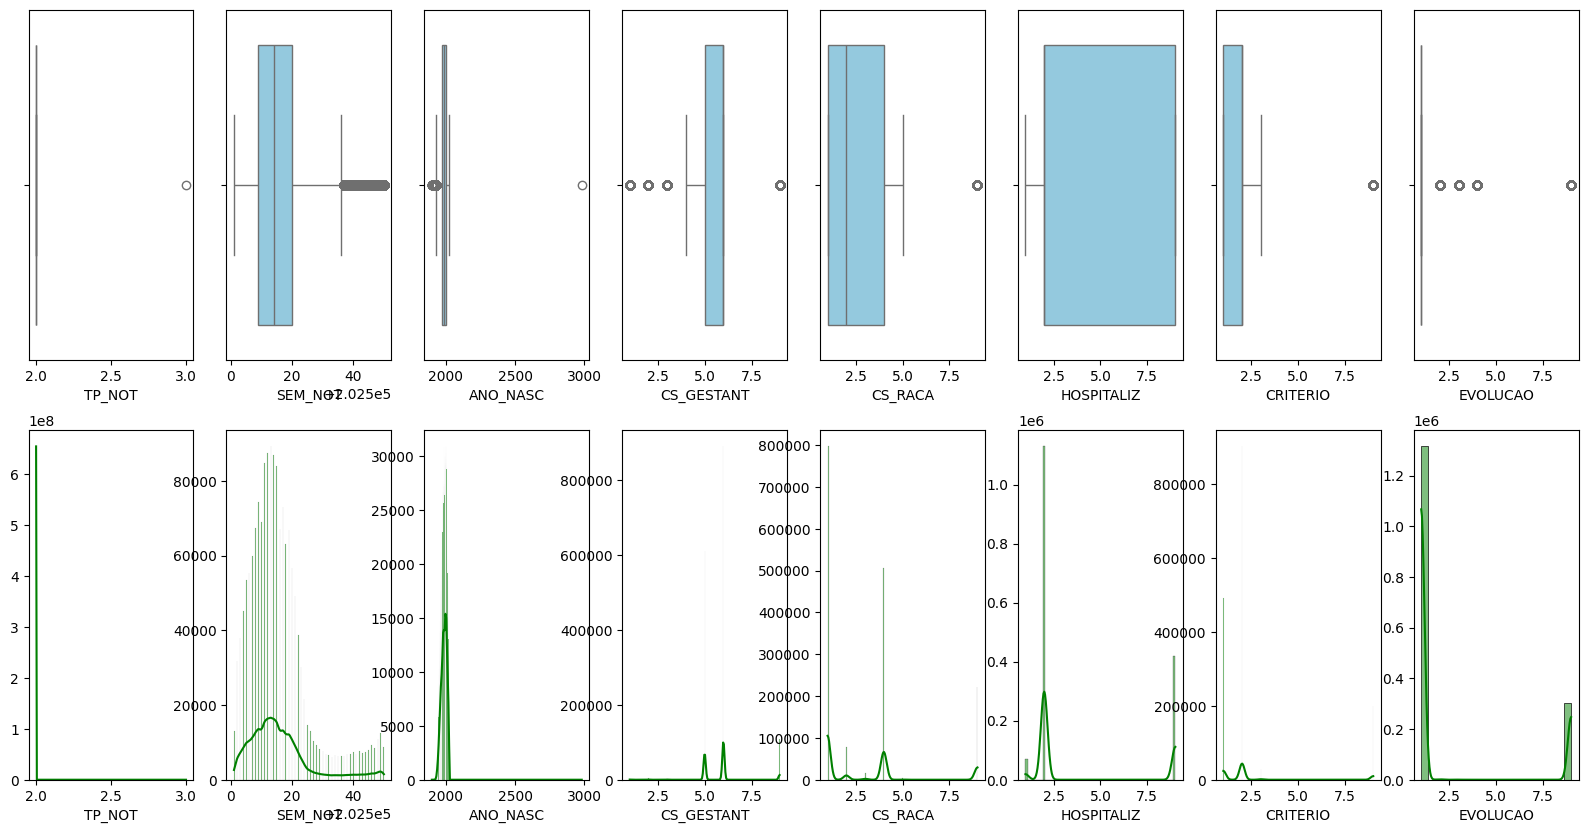

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

# MONTAR BOXPLOTS PARA VERIFICAR A DISTRIBUIÇÃO E OUTLIERS
numeric_cols = ['TP_NOT', 'SEM_NOT', 'ANO_NASC', 'CS_GESTANT', 'CS_RACA', 'HOSPITALIZ', 'CRITERIO', 'EVOLUCAO']

# Configurar uma grade de 2 e 8 colunas
fig, ax = plt.subplots(2, 8, figsize=(20, 10))

# Plotar os 14 gráficos
for i, col in enumerate(numeric_cols):
    # Linha 1 boxplots
    sns.boxplot(x=dados[col], ax=ax[0,i], color='skyblue')
    # Linha 2 histogramas
    sns.histplot(x=dados[col], ax=ax[1,i], color='green', kde=True)
    ax[1, i].set_ylabel('')

### Relação de registros de dengue pelos anos de nascimentos.

  Nos idosos a relação é de queda continua, mas aqui vemos melhor os dados que aparecem no outlier, do pessoal que nasceu no futuro, vamos tratar logo mais esses dados, talvez por mediana contando a partir do ano de 2025.

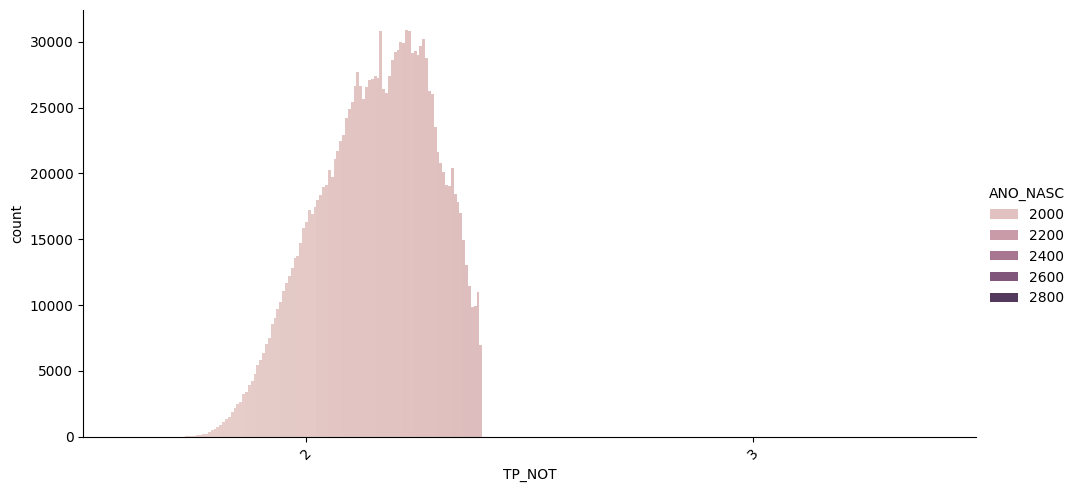

In [65]:
sns.catplot(
    data=dados,
    x="TP_NOT",
    hue="ANO_NASC",
    kind="count",
    height=5,
    aspect=2
)
plt.xticks(rotation=45)
plt.show()

### Percentual de tipos de notificação.

Abaixo conseguimos ver que 100% das notificações são individuais, vimos na análise de outliers que tinham no valor 3-surto, mas aqui está com 0%.

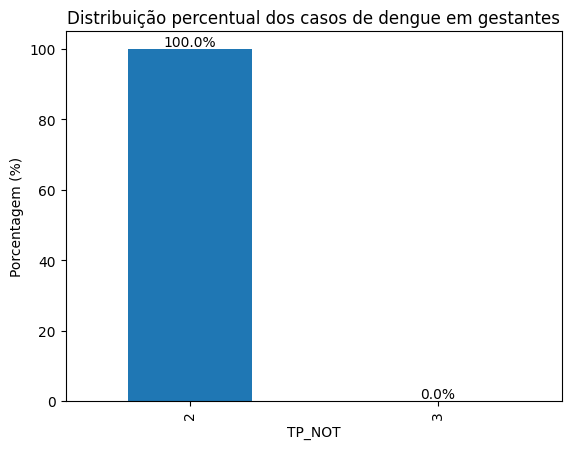

In [66]:
percentual = dados['TP_NOT'].value_counts(normalize=True) * 100

ax = percentual.plot(kind='bar')

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.ylabel('Porcentagem (%)')
plt.title('Distribuição percentual dos casos de dengue em gestantes')
plt.show()

### Percentual de registros de dengue em gestantes.

  Aqui é possivel analisar que o número de gestantes é pequeno, mas um dado importante pois pode trazer complicações na gestação, onde 1 ao 3 representa o trimestre de gestação, os demais não se enquadram a gestantes, podendo ser dados de homens, crianças, idosos(as), ou mulheres não gravidas.

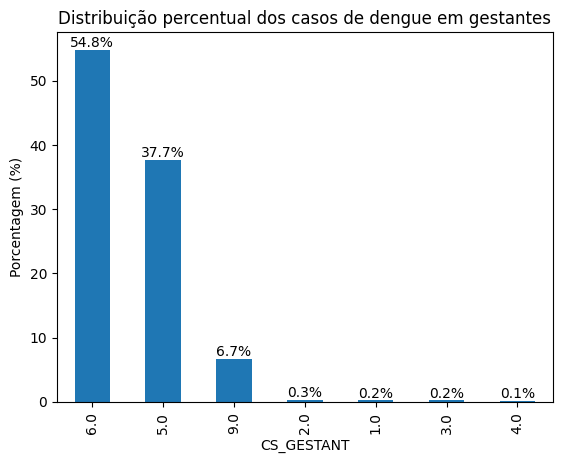

In [67]:
percentual = dados['CS_GESTANT'].value_counts(normalize=True) * 100

ax = percentual.plot(kind='bar')

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.ylabel('Porcentagem (%)')
plt.title('Distribuição percentual dos casos de dengue em gestantes')
plt.show()



### Percentual de notificações de dengue por hospitalizações.

  Abaixo conseguimos ver que 4% dos casos notificados foram hospitalizados, 70% não foram e 26% são dados não informados. Os dados de casos hospitalizados serão analisados melhor, pois são dados graves da evolução da dengue.

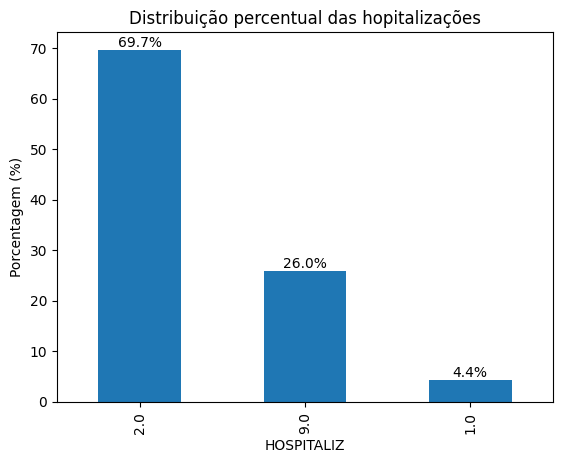

In [68]:
percentual = dados['HOSPITALIZ'].value_counts(normalize=True) * 100

ax = percentual.plot(kind='bar')

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.ylabel('Porcentagem (%)')
plt.title('Distribuição percentual das hopitalizações')
plt.show()

### Percentual de registros da evolução do quadro de dengue.

Abaixo conseguimos analizar que 83% das notificações tiveram cura, 0,1% tiveram óbito por agravo e o restante não foi informado.

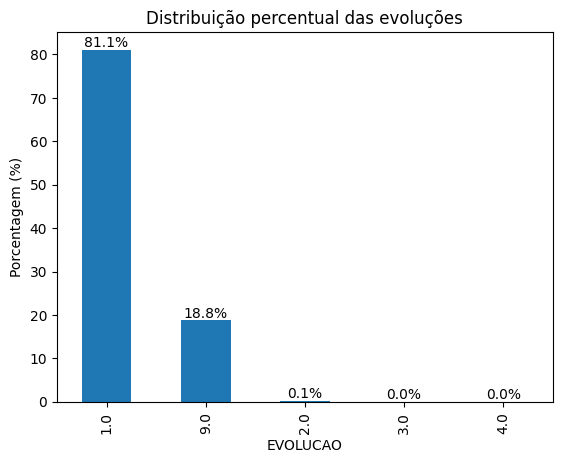

In [69]:
percentual = dados['EVOLUCAO'].value_counts(normalize=True) * 100

ax = percentual.plot(kind='bar')

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.ylabel('Porcentagem (%)')
plt.title('Distribuição percentual das evoluções')
plt.show()

### Relação dos tipos de notificações com sintomas.

  Os tipo de notificação é 2-Individual, e abaixo está os principais sintomas relados nos quadros de dengue, sendo a maioria febre, mialgia, cefaléia, naúsea e retro orbital.


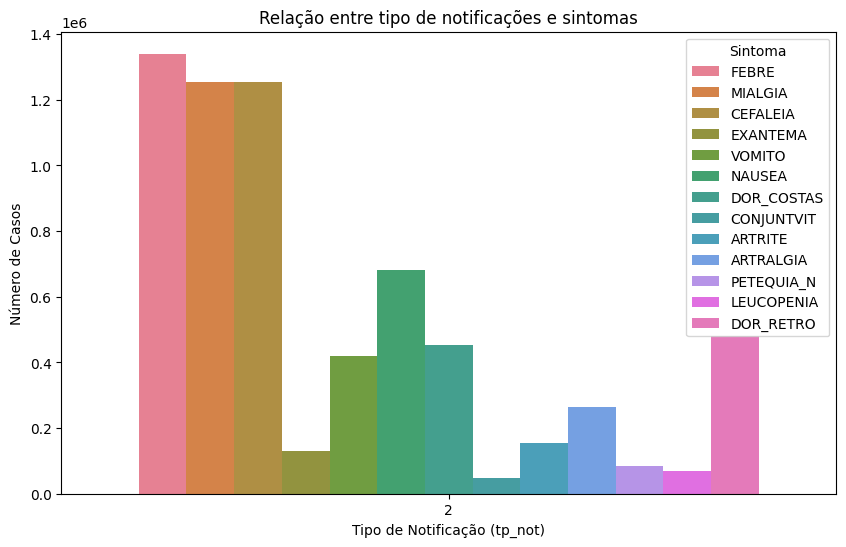

In [70]:
sintomas = ['FEBRE', 'MIALGIA', 'CEFALEIA', 'EXANTEMA', 'VOMITO', 'NAUSEA', 'DOR_COSTAS', 'CONJUNTVIT',  'ARTRITE',  'ARTRALGIA', 'PETEQUIA_N',  'LEUCOPENIA', 'DOR_RETRO']

df_plot = dados[['TP_NOT'] + sintomas].copy()

df_long = df_plot.melt(
    id_vars='TP_NOT',
    value_vars=sintomas,
    var_name='sintoma',
    value_name='presenca'
)

df_long = df_long[df_long['presenca'] == 1]

plt.figure(figsize=(10,6))
sns.countplot(
    data=df_long,
    x='TP_NOT',
    hue='sintoma'
)

plt.title('Relação entre tipo de notificações e sintomas')
plt.xlabel('Tipo de Notificação (tp_not)')
plt.ylabel('Número de Casos')
plt.legend(title='Sintoma')
plt.show()



### Relação dos tipos de notificações com casos de dengue graves.

Abaixo nos mostra os principais quadros de sintomas, sendo eles: insuficiência respiratória, taquicardia, extremidades frias, hipertensão, alteração da consciência e agravante entre outros orgãos.

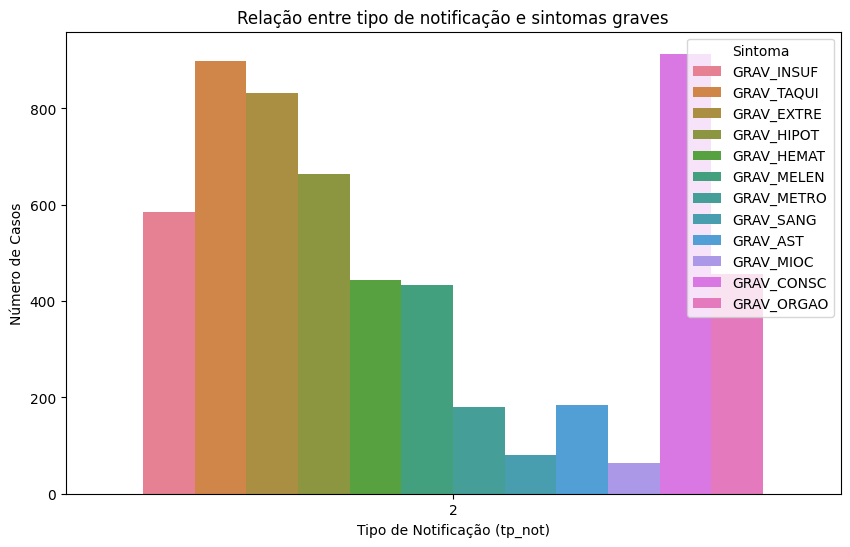

In [71]:
sintomas = ['GRAV_INSUF', 'GRAV_TAQUI', 'GRAV_EXTRE', 'GRAV_HIPOT', 'GRAV_HEMAT', 'GRAV_MELEN', 'GRAV_METRO', 'GRAV_SANG', 'GRAV_AST', 'GRAV_MIOC',  'GRAV_CONSC', 'GRAV_ORGAO']

df_plot = dados[['TP_NOT'] + sintomas].copy()

df_long = df_plot.melt(
    id_vars='TP_NOT',
    value_vars=sintomas,
    var_name='sintoma',
    value_name='presenca'
)

df_long = df_long[df_long['presenca'] == 1]

plt.figure(figsize=(10,6))
sns.countplot(
    data=df_long,
    x='TP_NOT',
    hue='sintoma'
)

plt.title('Relação entre tipo de notificação e sintomas graves')
plt.xlabel('Tipo de Notificação (tp_not)')
plt.ylabel('Número de Casos')
plt.legend(title='Sintoma')
plt.show()

### Relação dos tipos de notificações e doenças pré existentes.

Abaixo conseguimos ver que a maioria das pessoas que foram diagnosticadas com dengue tem hipertensão e diabetes.

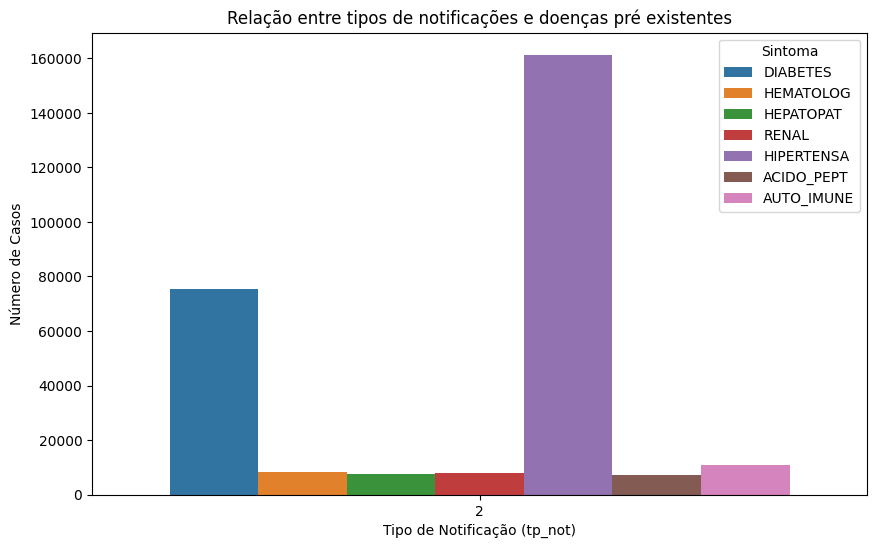

In [72]:
sintomas = ['DIABETES', 'HEMATOLOG', 'HEPATOPAT', 'RENAL', 'HIPERTENSA', 'ACIDO_PEPT', 'AUTO_IMUNE']

df_plot = dados[['TP_NOT'] + sintomas].copy()

df_long = df_plot.melt(
    id_vars='TP_NOT',
    value_vars=sintomas,
    var_name='sintoma',
    value_name='presenca'
)

df_long = df_long[df_long['presenca'] == 1]

plt.figure(figsize=(10,6))
sns.countplot(
    data=df_long,
    x='TP_NOT',
    hue='sintoma'
)

plt.title('Relação entre tipos de notificações e doenças pré existentes')
plt.xlabel('Tipo de Notificação (tp_not)')
plt.ylabel('Número de Casos')
plt.legend(title='Sintoma')
plt.show()

### Relação dos tipos de notificações por dengue e seus exames realizados para diagnóstico.

Abaixo conseguimos ver que foram realizados em sua maioria dos exames clínicos por Soro ELISA e Soro(IgM) Dengue.  

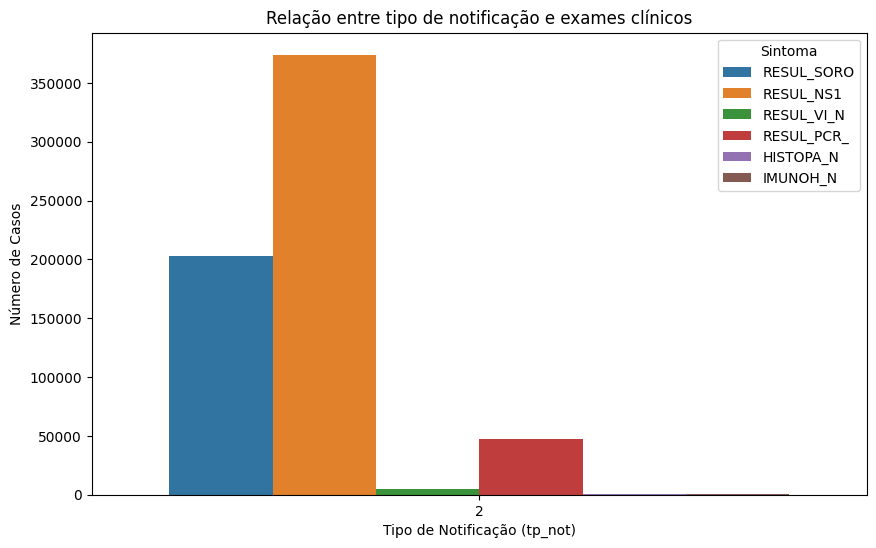

In [73]:
sintomas = ['RESUL_SORO', 'RESUL_NS1', 'RESUL_VI_N', 'RESUL_PCR_', 'HISTOPA_N', 'IMUNOH_N']

df_plot = dados[['TP_NOT'] + sintomas].copy()

df_long = df_plot.melt(
    id_vars='TP_NOT',
    value_vars=sintomas,
    var_name='sintoma',
    value_name='presenca'
)

df_long = df_long[df_long['presenca'] == 1]

plt.figure(figsize=(10,6))
sns.countplot(
    data=df_long,
    x='TP_NOT',
    hue='sintoma'
)

plt.title('Relação entre tipo de notificação e exames clínicos')
plt.xlabel('Tipo de Notificação (tp_not)')
plt.ylabel('Número de Casos')
plt.legend(title='Sintoma')
plt.show()

### Linha de números de casos de dengue por semana, em que o caso foi notificado.

Abaixo conseguimos ver que no primeiro trimestre os números de casos de dengue são exponencial, depois tem uma queda voltando ao ponto de casos da semana 1, onde a partir da semana 30 os casos ficam estáveis. Talvez tenha alguma relação com o clima como calor e época de chuvas ou secas dependendo das regiões, sendo que o Brasil é um país continental.

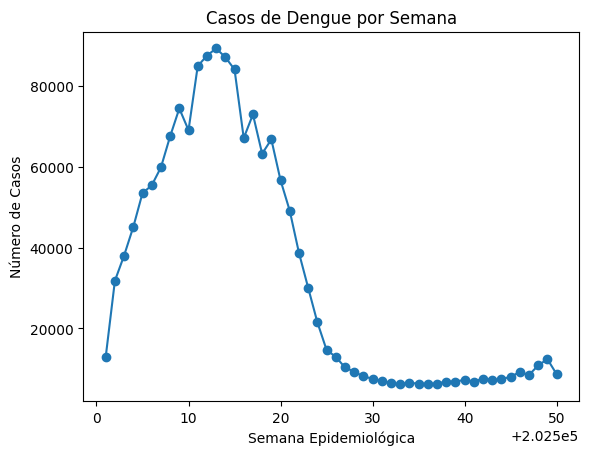

In [93]:
casos_semana = dados.groupby('SEM_NOT').size()

casos_semana.plot(kind='line', marker='o')
plt.xlabel('Semana Epidemiológica')
plt.ylabel('Número de Casos')
plt.title('Casos de Dengue por Semana')
plt.show()


### Linha de números de casos de dengue por semana, em que o foi constatado os primeiros sintomas.

Abaixo conseguimos ver que as variáveis SEM_NOT(Gráfico acima) e SEM_PRI, andam juntas nas mesmas tendências.

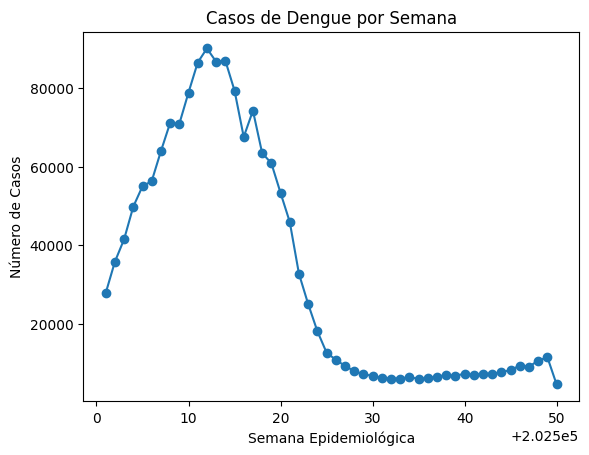

In [100]:
casos_semana = dados.groupby('SEM_PRI').size()

casos_semana.plot(kind='line', marker='o')
plt.xlabel('Semana Epidemiológica')
plt.ylabel('Número de Casos')
plt.title('Casos de Dengue por Semana')
plt.show()

### Linha de casos de dengue por UF.

Há um pico de casos na UF 35-SP, e 9 foram dados que não foram informados, na sequência temos a UF 31-MG e 52-GO.

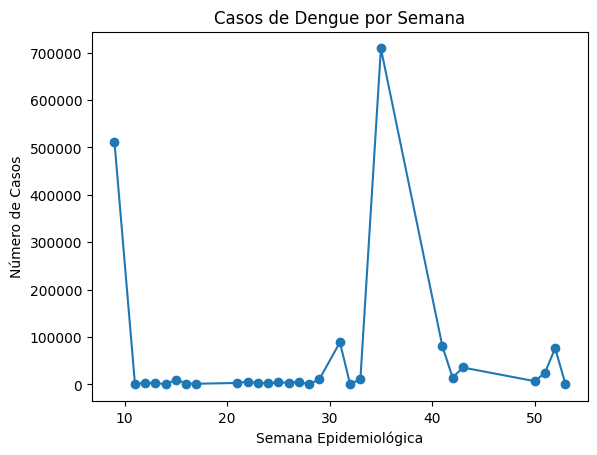

In [101]:
casos_semana = dados.groupby('COUFINF').size()

casos_semana.plot(kind='line', marker='o')
plt.xlabel('Semana Epidemiológica')
plt.ylabel('Número de Casos')
plt.title('Casos de Dengue por Semana')
plt.show()




### Abaixo temos a porcentagem por Unidade Federativa, e a mesma tendência é observada com relação ao gráfico de linhas acima.

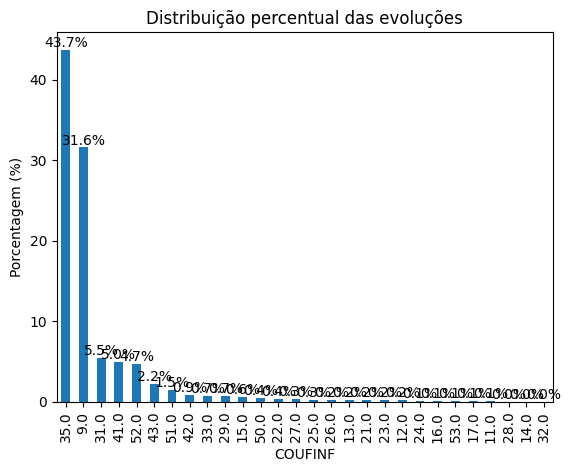

In [102]:
percentual = dados['COUFINF'].value_counts(normalize=True) * 100

ax = percentual.plot(kind='bar')

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.ylabel('Porcentagem (%)')
plt.title('Distribuição percentual das evoluções')
plt.show()

Correlação.

TP_NOT        1.000000
SEM_PRI       0.002490
CS_GESTANT    0.002453
SEM_NOT       0.002430
CRITERIO      0.002060
                ...   
ALRM_HEPAT         NaN
ALRM_LIQ           NaN
GRAV_PULSO         NaN
GRAV_CONV          NaN
GRAV_ENCH          NaN
Name: TP_NOT, Length: 73, dtype: float64


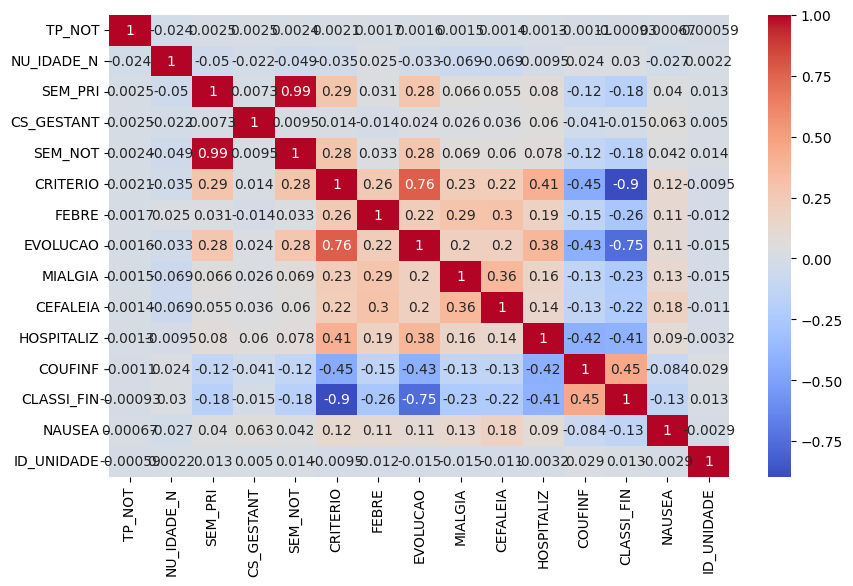

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

import numpy as np

df_num = dados.select_dtypes(include=['int64', 'float64'])


df_num = df_num.loc[:, df_num.nunique() > 1]

corr_target = df_num.corr()['TP_NOT']
corr_target = corr_target.sort_values(ascending=False)

print(corr_target)

top = corr_target.abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(10, 6))
sns.heatmap(df_num[top].corr(), annot=True, cmap='coolwarm')
plt.show()
